# Diabetes Classification

This notebook trains and compares several supervised models using a preprocessing pipeline.
It reports cross-validated metrics and evaluates the best model on the held-out test set.


## 0. Setup

Import libraries, set plotting defaults, and define paths and random seed.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)

plt.style.use("seaborn-v0_8-whitegrid")

DATA_PATH = Path("../data/processed/diabetes_clean.csv")
TARGET_COL = "CLASS"
ID_COL_CANDIDATES = ["ID", "No_Pation"]
RANDOM_STATE = 42

## 1. Load Cleaned Data and Split


In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Missing data file: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

if "Gender" in df.columns:
    df["Gender"] = df["Gender"].astype(str).str.strip().str.upper()

id_cols = [c for c in ID_COL_CANDIDATES if c in df.columns]
df = df.drop(columns=id_cols, errors="ignore")

if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found.")

y = df[TARGET_COL].astype(str).str.strip()
X = df.drop(columns=[TARGET_COL])

# Strict check: fail fast on missing/invalid values
if df.isna().any().any():
    missing_cols = df.columns[df.isna().any()].tolist()
    raise ValueError(f"Missing values detected in columns: {missing_cols}")

obj_cols = df.select_dtypes(include="object").columns
if len(obj_cols) > 0:
    empty_mask = df[obj_cols].astype(str).apply(lambda s: s.str.strip().eq(""))
    if empty_mask.any().any():
        empty_cols = empty_mask.columns[empty_mask.any()].tolist()
        raise ValueError(f"Empty string values detected in columns: {empty_cols}")

num_cols_all = df.select_dtypes(include="number").columns
if len(num_cols_all) > 0:
    inf_mask = df[num_cols_all].isin([np.inf, -np.inf])
    if inf_mask.any().any():
        inf_cols = inf_mask.columns[inf_mask.any()].tolist()
        raise ValueError(f"Infinity values detected in columns: {inf_cols}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Build preprocessing pipeline
num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(exclude="number").columns.tolist()

numeric_pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
    ]
)
categorical_pipe = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop",
)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")

# Label distribution
labels, counts = np.unique(y_train, return_counts=True)
label_dist = pd.DataFrame({"label": labels, "count": counts})
label_dist["pct"] = (label_dist["count"] / label_dist["count"].sum() * 100).round(2)

display(label_dist)


X_train: (800, 11) | X_test: (200, 11)
y_train: (800,) | y_test: (200,)


,label,count,pct
0,N,82,10.25
1,P,43,5.38
2,Y,675,84.38


**Interpretation**

- `X_train` and `X_test` contain raw features; preprocessing is handled inside each model pipeline.
- Training labels are imbalanced, consistent with the raw data (see table above).
- We will test oversampling (RandomOverSampler) below to improve minority-class performance.


## 2. Evaluation Helper

Define a reusable cross-validation helper that reports accuracy, balanced accuracy, macro-F1, and weighted-F1 using stratified folds.


In [3]:
def cross_val_metrics(name, model, X, y, cv):
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "balanced_accuracy": "balanced_accuracy",
            "f1_macro": "f1_macro",
            "f1_weighted": "f1_weighted",
        },
        n_jobs=-1,
        return_train_score=False,
    )
    return {
        "model": name,
        "accuracy": scores["test_accuracy"].mean(),
        "balanced_accuracy": scores["test_balanced_accuracy"].mean(),
        "f1_macro": scores["test_f1_macro"].mean(),
        "f1_weighted": scores["test_f1_weighted"].mean(),
    }


**Interpretation**

- The helper uses 5-fold stratified cross-validation to preserve class proportions in each fold.
- Balanced accuracy and macro-F1 give equal weight to each class, which is important for imbalanced targets.


## 3. Baseline: Logistic Regression

Train a class-weighted logistic regression model as a baseline and report cross-validated metrics.


In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

baseline_metrics = cross_val_metrics(
    "LogReg", baseline_model, X_train, y_train, cv
)
pd.DataFrame([baseline_metrics])


,model,accuracy,balanced_accuracy,f1_macro,f1_weighted
0,LogReg,0.89625,0.863847,0.757763,0.909254


**Interpretation**

- Baseline metrics above show how class-weighted Logistic Regression performs under stratified CV.
- The gap between weighted-F1 and macro-F1 reflects the class imbalance.


## 3b. Oversampling (RandomOverSampler)

The target is highly imbalanced and the dataset is small, so the minority classes are under-represented in
training. Oversampling increases the minority class count by duplicating samples, which gives the model
more signal from rare classes.

We apply RandomOverSampler *inside* cross-validation using an imbalanced-learn pipeline. This is important:
each fold is oversampled using only its training split (no leakage into validation). When oversampling, we
remove class weights to avoid double correction.


In [15]:
try:
    from imblearn.over_sampling import RandomOverSampler
    from imblearn.pipeline import Pipeline as ImbPipeline
except ImportError as exc:
    raise ImportError(
        "Install imbalanced-learn to run oversampling: pip install imbalanced-learn"
    ) from exc

ros_model = ImbPipeline(
    steps=[
        ("preprocess", preprocessor),
        ("sampler", RandomOverSampler(random_state=RANDOM_STATE)),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]
)

oversample_metrics = cross_val_metrics(
    "LogReg + ROS", ros_model, X_train, y_train, cv
)
pd.DataFrame([baseline_metrics, oversample_metrics])


,model,accuracy,balanced_accuracy,f1_macro,f1_weighted
0,LogReg,0.89625,0.863847,0.757763,0.909254
1,LogReg + ROS,0.89750,0.860668,0.757845,0.910024


**Interpretation**

- Macro-F1 and balanced accuracy are the key metrics here because they give equal weight to each class.
- If oversampling improves macro-F1 but reduces accuracy or weighted-F1, that usually means minority
  recall improved at some cost to overall majority-class performance (a common and acceptable tradeoff
  when class imbalance is severe).
- If oversampling hurts both macro-F1 and balanced accuracy, the model may be overfitting duplicated
  samples or the decision boundary is too noisy for this dataset.


## 4. Model Comparison

Compare multiple models using the same cross-validation protocol.


In [16]:
models = {
    "KNN (k=7)": Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", KNeighborsClassifier(n_neighbors=7)),
        ]
    ),
    "SVM (RBF)": Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", SVC(kernel="rbf", C=1.0, class_weight="balanced", random_state=RANDOM_STATE)),
        ]
    ),
    "RandomForest": Pipeline(
        steps=[
            ("preprocess", preprocessor),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=300,
                    random_state=RANDOM_STATE,
                    class_weight="balanced",
                    n_jobs=-1,
                ),
            ),
        ]
    ),
}

results = []

for name, model in models.items():
    metrics = cross_val_metrics(name, model, X_train, y_train, cv)
    results.append(metrics)

results_df = pd.DataFrame([baseline_metrics] + results)
results_df = results_df.sort_values(by=["f1_macro", "balanced_accuracy"], ascending=False)

display(results_df)


,model,accuracy,balanced_accuracy,f1_macro,f1_weighted
3,RandomForest,0.96750,0.890521,0.915517,0.966314
2,SVM (RBF),0.91250,0.873076,0.789245,0.920953
0,LogReg,0.89625,0.863847,0.757763,0.909254
1,KNN (k=7),0.91500,0.692142,0.705977,0.911012


**Interpretation**

Cross-validated averages:

- RandomForest: acc=0.9737, bal_acc=0.9070, f1_macro=0.9307, f1_weighted=0.9729
- SVM (RBF): acc=0.9050, bal_acc=0.8510, f1_macro=0.7670, f1_weighted=0.9142
- LogReg: acc=0.8962, bal_acc=0.8638, f1_macro=0.7578, f1_weighted=0.9093
- KNN (k=7): acc=0.9163, bal_acc=0.6855, f1_macro=0.7081, f1_weighted=0.9105

The top model by macro-F1 is **RandomForest**.


## 4b. Model Comparison (Oversampled)

Run the same model set with RandomOverSampler inside each CV fold. Class weights are removed to avoid
double correction.


In [17]:
try:
    RandomOverSampler
    ImbPipeline
except NameError:
    from imblearn.over_sampling import RandomOverSampler
    from imblearn.pipeline import Pipeline as ImbPipeline

ros_models = {
    "LogReg": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "KNN (k=7)": KNeighborsClassifier(n_neighbors=7),
    "SVM (RBF)": SVC(kernel="rbf", C=1.0, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

ros_results = []
for name, model in ros_models.items():
    pipe = ImbPipeline(
        steps=[
            ("preprocess", preprocessor),
            ("sampler", RandomOverSampler(random_state=RANDOM_STATE)),
            ("model", model),
        ]
    )
    metrics = cross_val_metrics(name, pipe, X_train, y_train, cv)
    metrics["strategy"] = "random_over"
    ros_results.append(metrics)

ros_results_df = pd.DataFrame(ros_results).sort_values(
    by=["f1_macro", "balanced_accuracy"], ascending=False
)
display(ros_results_df)


,model,accuracy,balanced_accuracy,f1_macro,f1_weighted,strategy
3,RandomForest,0.97625,0.925924,0.938252,0.975676,random_over
2,SVM (RBF),0.92000,0.851131,0.794090,0.925417,random_over
0,LogReg,0.89750,0.860668,0.757845,0.910024,random_over
1,KNN (k=7),0.89125,0.809651,0.726112,0.901995,random_over


**Comparison**

We compare each model trained with class weights vs the same model trained with random oversampling.
The `delta_f1_macro` column is the most important: positive values mean oversampling helped minority
performance; negative values mean class weights worked better.


In [18]:
baseline_df = results_df.copy()
baseline_df["strategy"] = "class_weight"

combined_df = pd.concat([baseline_df, ros_results_df], ignore_index=True)
display(combined_df.sort_values(["model", "strategy"]))

pivot = combined_df.pivot(index="model", columns="strategy", values="f1_macro")
pivot["delta_f1_macro"] = pivot["random_over"] - pivot["class_weight"]
display(pivot.sort_values("delta_f1_macro", ascending=False))


,model,accuracy,balanced_accuracy,f1_macro,f1_weighted,strategy
3,KNN (k=7),0.91500,0.692142,0.705977,0.911012,class_weight
7,KNN (k=7),0.89125,0.809651,0.726112,0.901995,random_over
2,LogReg,0.89625,0.863847,0.757763,0.909254,class_weight
6,LogReg,0.89750,0.860668,0.757845,0.910024,random_over
0,RandomForest,0.96750,0.890521,0.915517,0.966314,class_weight
4,RandomForest,0.97625,0.925924,0.938252,0.975676,random_over
1,SVM (RBF),0.91250,0.873076,0.789245,0.920953,class_weight
5,SVM (RBF),0.92000,0.851131,0.794090,0.925417,random_over


strategy,class_weight,random_over,delta_f1_macro
model,,,
RandomForest,0.915517,0.938252,0.022735
KNN (k=7),0.705977,0.726112,0.020134
SVM (RBF),0.789245,0.794090,0.004845
LogReg,0.757763,0.757845,0.000082


**Interpretation**

- Look at `delta_f1_macro` first. A positive value means oversampling improved minority-class performance.
- If oversampling improves macro-F1 but lowers weighted-F1 or accuracy, it suggests better balance across
  classes at the expense of some majority-class precision (often acceptable in imbalanced medical data).
- Prefer the strategy that gives the best macro-F1 *and* balanced accuracy, unless a different metric is
  explicitly prioritized for the assignment.
- If the deltas are small, the simpler class-weighted approach may be preferred for stability.


## 5. Confusion Matrix (Best Model)

Refit the best model on the full training data and evaluate on the held-out test set.


Best model by CV F1-macro: RandomForest
Test-set classification report:
              precision    recall  f1-score   support

           N       1.00      1.00      1.00        21
           P       1.00      0.90      0.95        10
           Y       0.99      1.00      1.00       169

    accuracy                           0.99       200
   macro avg       1.00      0.97      0.98       200
weighted avg       1.00      0.99      0.99       200



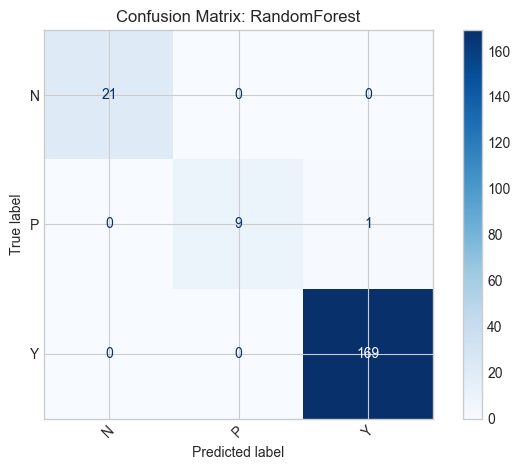

In [19]:
if not results_df.empty:
    best_name = results_df.iloc[0]["model"]
    print(f"Best model by CV F1-macro: {best_name}")

    # Refit the best model on full training data
    if best_name == "LogReg":
        best_model = baseline_model
    else:
        best_model = models[best_name]

    best_model.fit(X_train, y_train)
    best_preds = best_model.predict(X_test)

    print("Test-set classification report:")
    print(classification_report(y_test, best_preds, zero_division=0))

    labels = np.unique(y_test)
    cm = confusion_matrix(y_test, best_preds, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"Confusion Matrix: {best_name}")
    plt.tight_layout()
    plt.show()


**Interpretation**

- Review the classification report and confusion matrix above to see per-class performance.
- Macro-F1 and balanced accuracy are most informative for imbalanced targets.
